In [1]:
import scanpy as sc
import pandas as pd
from scipy import io, sparse
import scipy
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.patches as mpatches
import numpy as np

In [2]:
adata_ductal = sc.read_h5ad('epithelial.h5ad')
# remove MALAT1 lo cluster https://www.biorxiv.org/content/10.1101/2024.07.14.603469v1
adata_ductal = adata_ductal[~(adata_ductal.obs.leiden_annotated == 'pancreatic ductal cell_GAPDH_RPLP1'),:]
adata_ductal = adata_ductal[~(adata_ductal.obs.leiden_annotated == 'pancreatic ductal cell_SST_INS'),:]

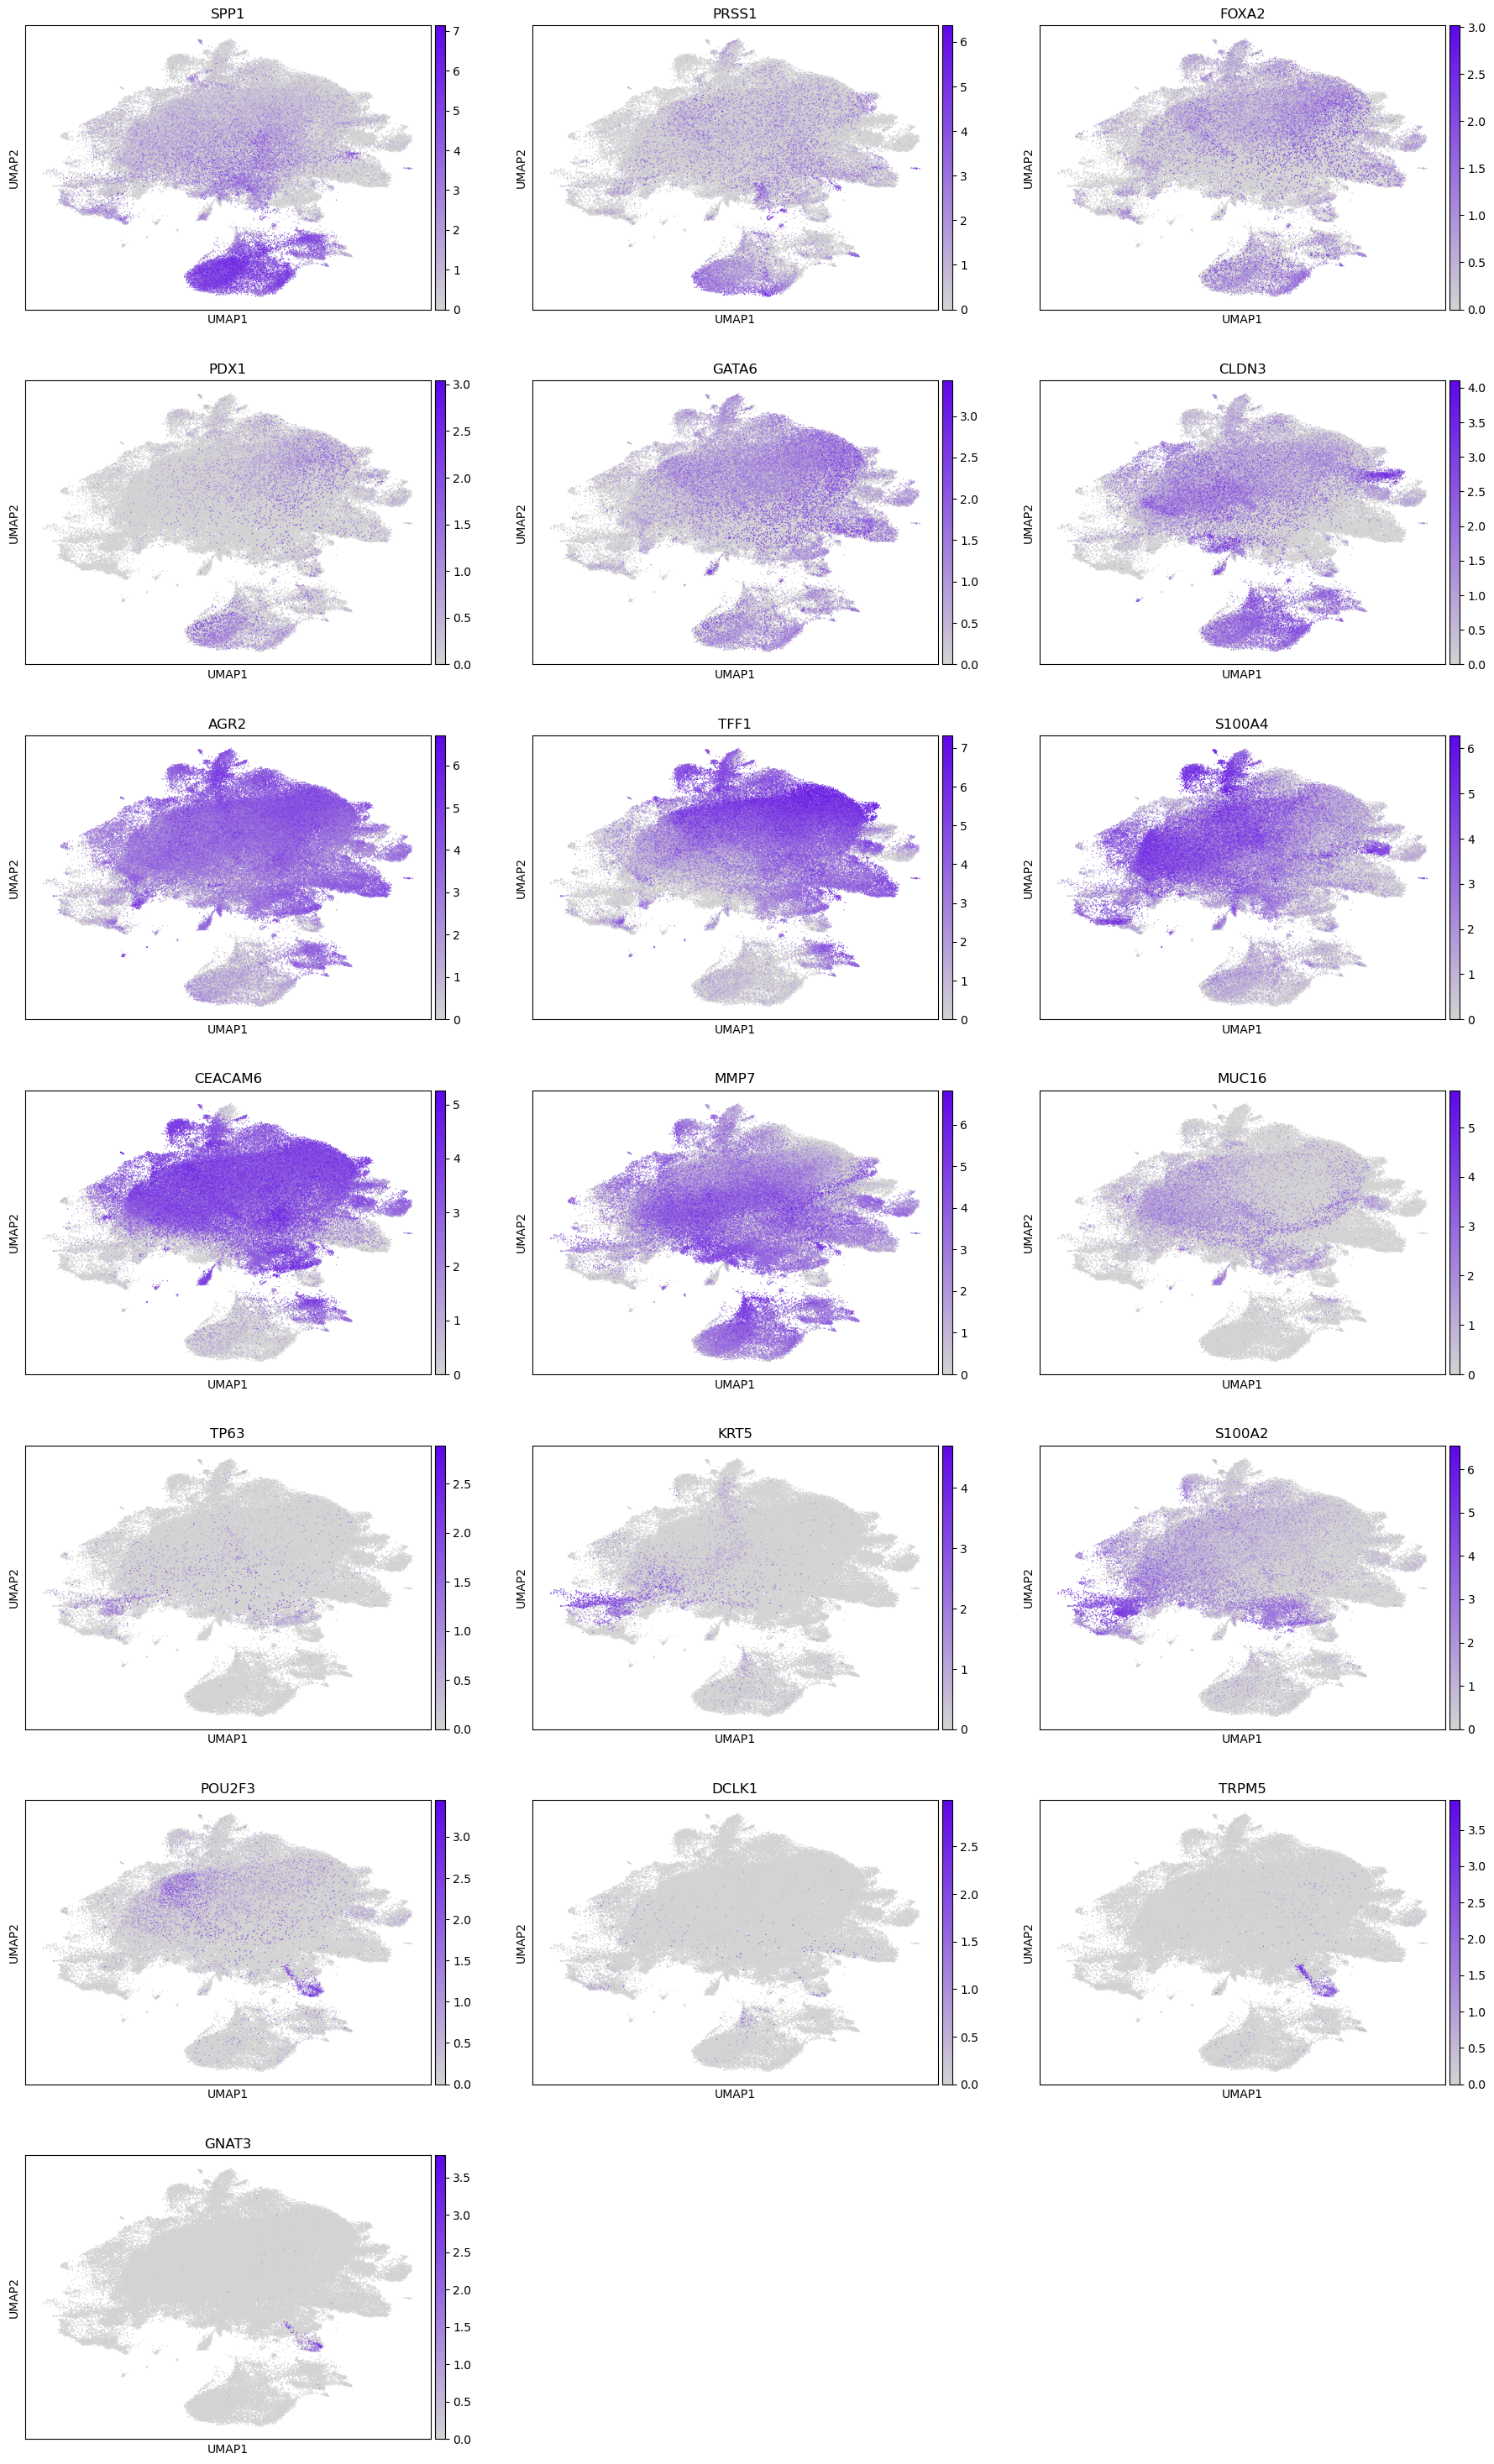

In [3]:
genes_plot = [ 'SPP1','PRSS1', # EX
              'FOXA2','PDX1','GATA6', # edTF
              'CLDN3','AGR2','TFF1', # Classical genes (low / missing edTFnull)
              'S100A4', # S100A4+
              'CEACAM6','MMP7','MUC16', # can be in edTFnull
              'TP63','KRT5','S100A2', # Basal
              'POU2F3', 'DCLK1','TRPM5','GNAT3' # Tuft cells
             ]
sc.pl.umap(adata_ductal, color = genes_plot, size = 4, ncols = 3, cmap=sns.blend_palette(["lightgray", sns.xkcd_rgb["blue violet"]], as_cmap=True)
)

/var/folders/wp/m71mqb5d54xdh2pz4bmqqtbh0000gp/T/ipykernel_23355/803290469.py:14: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_ductal.obs['EX'] = (spp1 > thresh_spp1) | (prss1 > thresh_prss1)


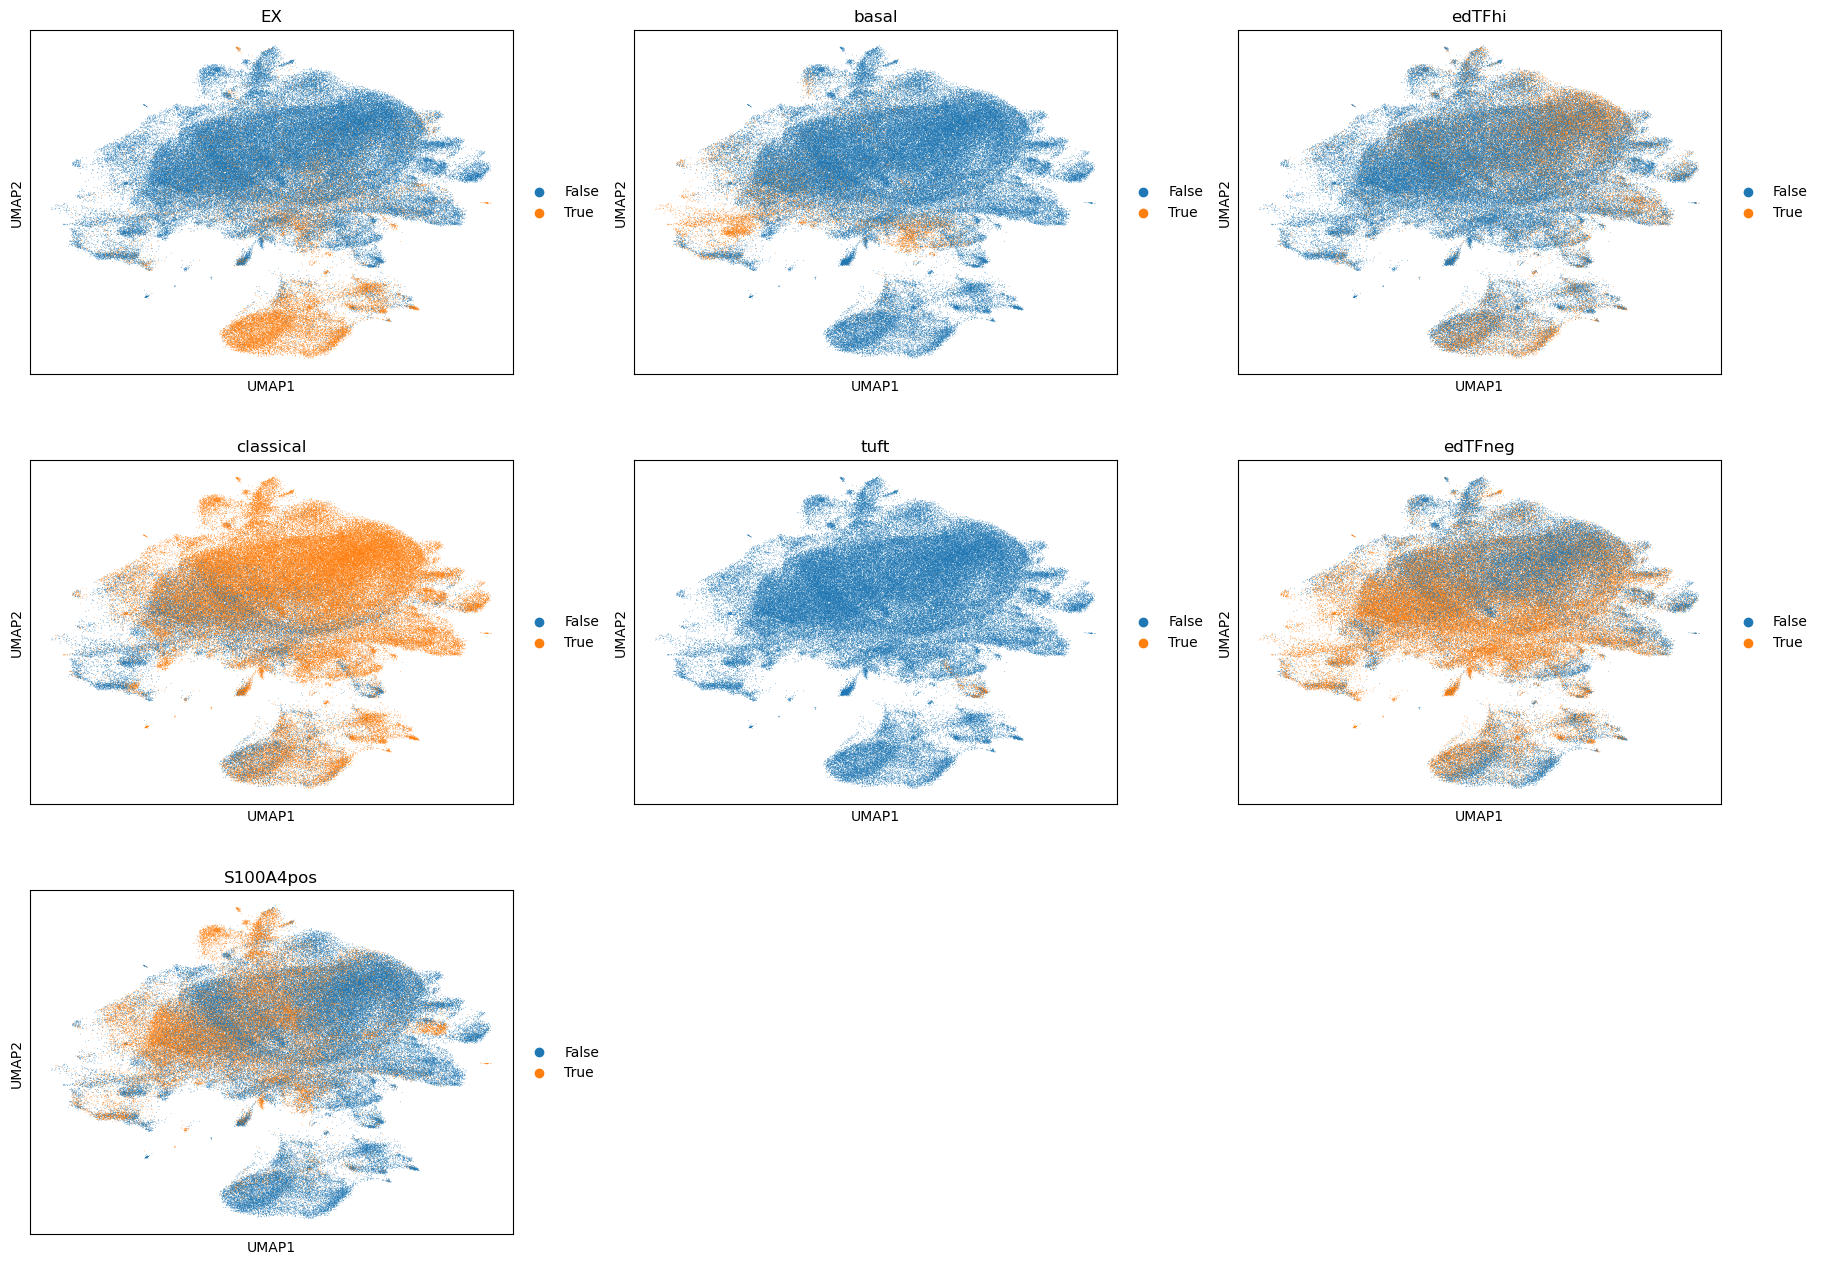

In [4]:
def get_expr(adata, gene):
    if gene in adata.var_names:
        vals = adata[:, gene].X
    else:
        vals = adata.raw[:, gene].X
    return np.asarray(vals.todense()).flatten() if hasattr(vals, "todense") else np.asarray(vals).flatten()

spp1 = get_expr(adata_ductal, 'SPP1')
prss1 = get_expr(adata_ductal, 'PRSS1')

thresh_spp1 = 0.25 * spp1.max()
thresh_prss1 = 0.25 * prss1.max()

adata_ductal.obs['EX'] = (spp1 > thresh_spp1) | (prss1 > thresh_prss1)

tp63 = get_expr(adata_ductal, 'TP63')
krt5 = get_expr(adata_ductal, 'KRT5')
s100a2 = get_expr(adata_ductal, 'S100A2')

thresh_tp63 = 0.25 * tp63.max()
thresh_krt5 = 0.25 * krt5.max()
thresh_s100a2 = 0.25 * s100a2.max()

adata_ductal.obs['basal'] = (
    (tp63 > thresh_tp63) |
    (krt5 > thresh_krt5) |
    (s100a2 > thresh_s100a2)
)

foxa2 = get_expr(adata_ductal, 'FOXA2')
pdx1 = get_expr(adata_ductal, 'PDX1')
gata6 = get_expr(adata_ductal, 'GATA6')

thresh_foxa2 = 0.25 * foxa2.max()
thresh_pdx1 = 0.25 * pdx1.max()
thresh_gata6 = 0.25 * gata6.max()

adata_ductal.obs['edTFhi'] = (
    (foxa2 > thresh_foxa2) |
    (pdx1 > thresh_pdx1) |
    (gata6 > thresh_gata6)
)

agr2 = get_expr(adata_ductal, 'AGR2')
tff1 = get_expr(adata_ductal, 'TFF1')
cldn3 = get_expr(adata_ductal, 'CLDN3')

thresh_cldn3 = 0.25 * cldn3.max()
thresh_agr2 = 0.25 * agr2.max()
thresh_tff1 = 0.25 * tff1.max()

adata_ductal.obs['classical'] = (
    (cldn3 > thresh_cldn3) |
    (agr2 > thresh_agr2) |
    (tff1 > thresh_tff1)
)

pou2f3 = get_expr(adata_ductal, 'POU2F3')
trpm5 = get_expr(adata_ductal, 'TRPM5')
gnat3 = get_expr(adata_ductal, 'GNAT3')

thresh_pou2f3 = 0.2 * pou2f3.max()
thresh_trpm5 = 0.2 * trpm5.max()
thresh_gnat3 = 0.2 * gnat3.max()

pass_pou2f3 = pou2f3 > thresh_pou2f3
pass_trpm5 = trpm5 > thresh_trpm5
pass_gnat3 = gnat3 > thresh_gnat3

n_pass = pass_pou2f3.astype(int) + pass_trpm5.astype(int) + pass_gnat3.astype(int)

adata_ductal.obs['tuft'] = n_pass >= 2

thresh_foxa2_low = 0.005 * foxa2.max()
thresh_pdx1_low = 0.005 * pdx1.max()
thresh_gata6_low = 0.005 * gata6.max()

adata_ductal.obs['edTFneg'] = (
    (foxa2 <= thresh_foxa2_low) &
    (pdx1 <= thresh_pdx1_low) &
    (gata6 <= thresh_gata6_low)
)

s100a4 = get_expr(adata_ductal, 'S100A4')
thresh_s100a4 = 0.25 * s100a4.max()
adata_ductal.obs['S100A4pos'] = s100a4 > thresh_s100a4

sc.pl.umap(adata_ductal, color=['EX', 'basal','edTFhi', 'classical','tuft','edTFneg','S100A4pos'], size=1, ncols =3)

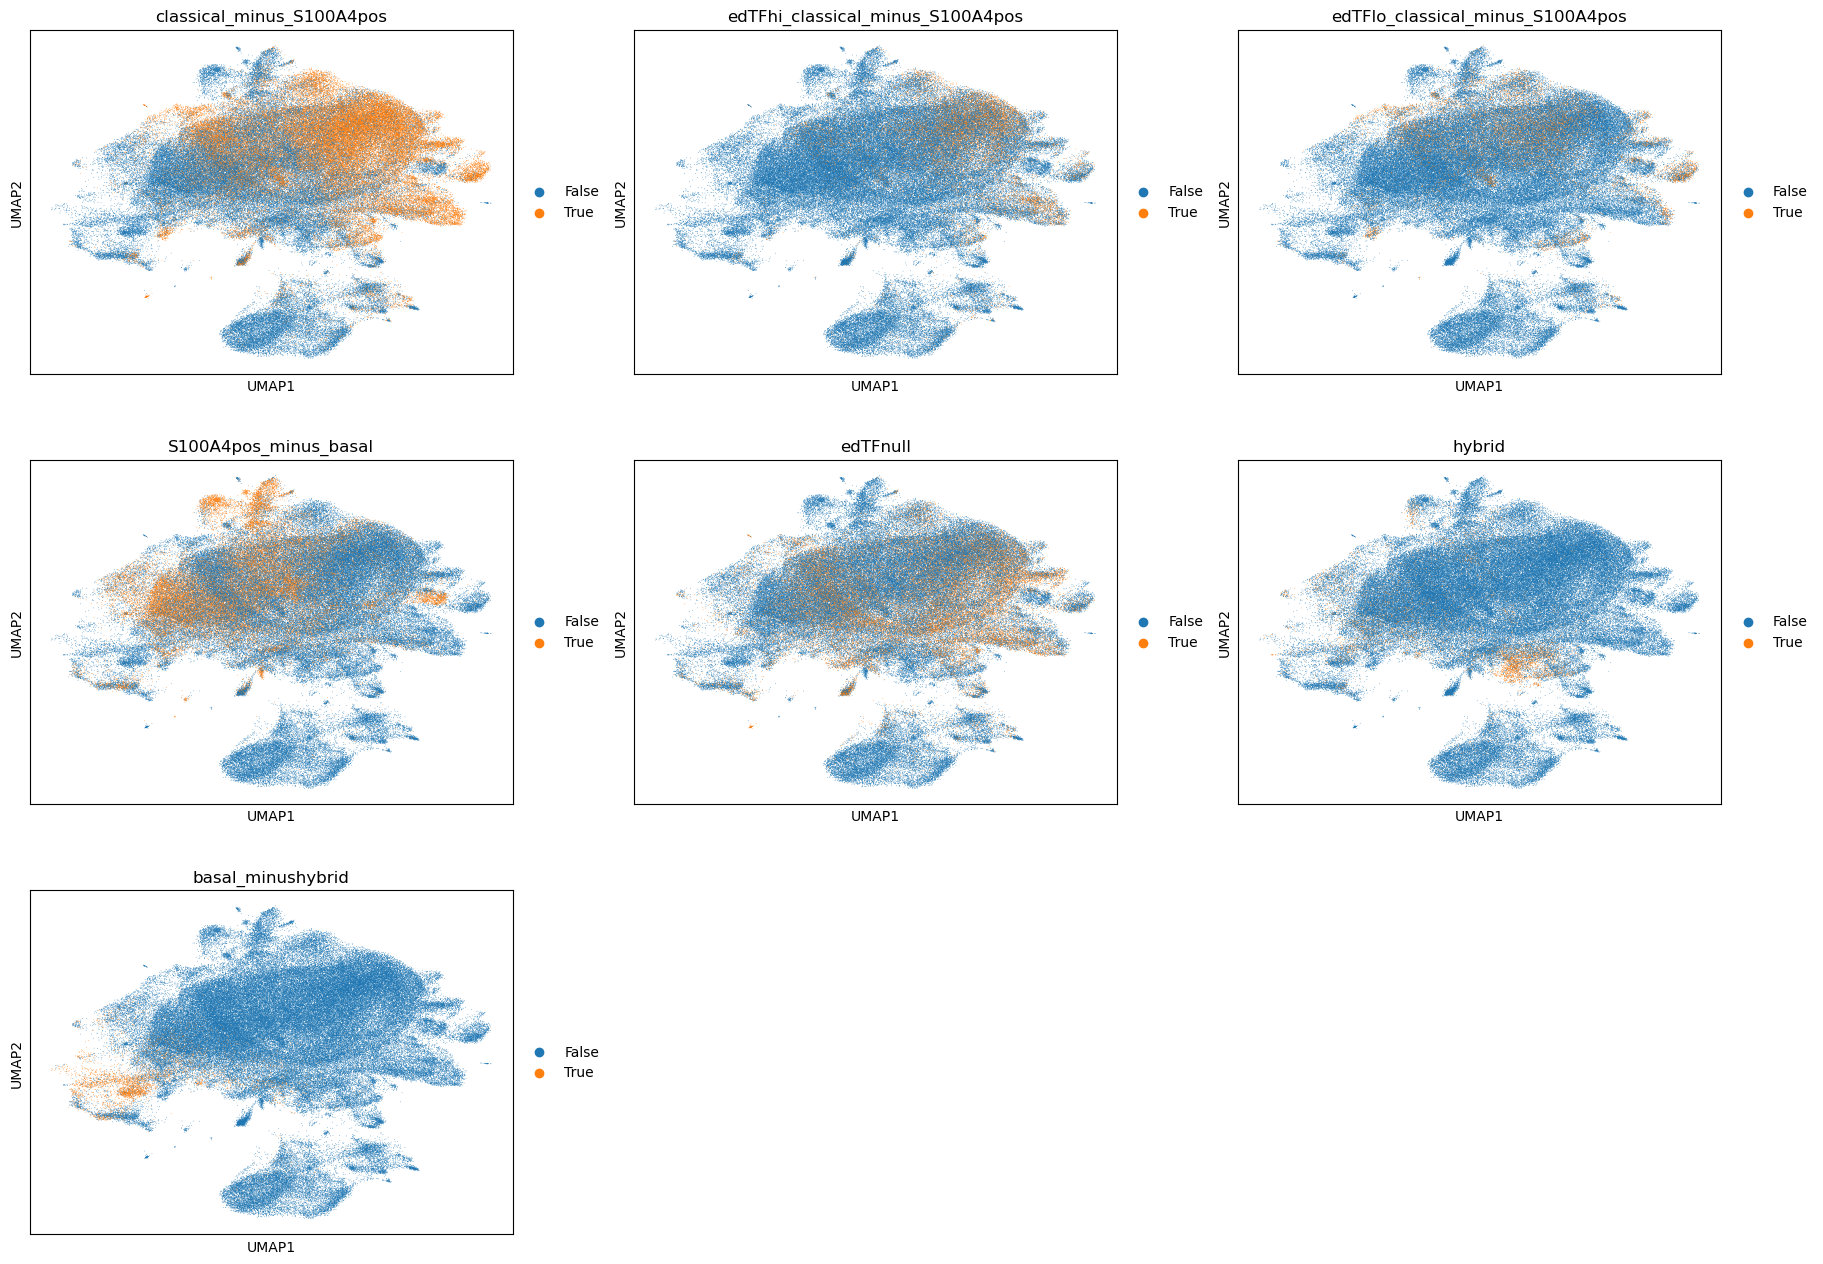

In [5]:
adata_ductal.obs['hybrid'] = (
    adata_ductal.obs['classical'] &
    adata_ductal.obs['basal'] &
     ~adata_ductal.obs['tuft'] 
)

adata_ductal.obs['classical_minus_S100A4pos'] = (
    adata_ductal.obs['classical'] & ~adata_ductal.obs['S100A4pos'] & ~adata_ductal.obs['EX'] & ~adata_ductal.obs['hybrid'] & ~adata_ductal.obs['tuft'] 
)
adata_ductal.obs['edTFhi_classical_minus_S100A4pos'] = (
    adata_ductal.obs['edTFhi'] & adata_ductal.obs['classical'] & ~adata_ductal.obs['S100A4pos']  & ~adata_ductal.obs['EX']  & ~adata_ductal.obs['hybrid']  & ~adata_ductal.obs['tuft'] 
)
adata_ductal.obs['edTFlo_classical_minus_S100A4pos'] = (
    ~adata_ductal.obs['edTFhi'] &  ~adata_ductal.obs['edTFneg'] & adata_ductal.obs['classical'] & ~adata_ductal.obs['S100A4pos'] & ~adata_ductal.obs['EX'] & ~adata_ductal.obs['hybrid']  & ~adata_ductal.obs['tuft'] 
)

adata_ductal.obs['S100A4pos_minus_basal'] = (
    adata_ductal.obs['S100A4pos'] & ~adata_ductal.obs['EX'] & ~adata_ductal.obs['basal']  & ~adata_ductal.obs['hybrid']  & ~adata_ductal.obs['tuft'] 
)

# Here I define edTFnull as NOT(AGR2+TFF1+)
adata_ductal.obs['edTFnull_old'] = ~(
    adata_ductal.obs['classical'] |
    adata_ductal.obs['basal'] |
    adata_ductal.obs['EX'] | 
    adata_ductal.obs['tuft'] |
    adata_ductal.obs['S100A4pos']
)

adata_ductal.obs['edTFnull'] = (
    adata_ductal.obs['edTFneg'] &  ~adata_ductal.obs['S100A4pos'] & ~adata_ductal.obs['EX'] & ~adata_ductal.obs['hybrid']  & ~adata_ductal.obs['tuft'] &  ~adata_ductal.obs['basal']
)

adata_ductal.obs['basal_minushybrid'] = (
    adata_ductal.obs['basal'] &
     ~adata_ductal.obs['tuft'] &
     ~adata_ductal.obs['hybrid']
)


sc.pl.umap(adata_ductal, color=['classical_minus_S100A4pos','edTFhi_classical_minus_S100A4pos','edTFlo_classical_minus_S100A4pos',
                                'S100A4pos_minus_basal','edTFnull', 'hybrid','basal_minushybrid'], 
           size=1, ncols = 3)

In [6]:
cols = ['edTFhi_classical_minus_S100A4pos',
        'edTFlo_classical_minus_S100A4pos', 'S100A4pos_minus_basal',
        'edTFnull', 'hybrid', 'tuft','basal_minushybrid']

size_table = pd.DataFrame({
    'n_cells': [adata_ductal.obs[c].sum() for c in cols]
}, index=cols)

size_table

,n_cells
edTFhi_classical_minus_S100A4pos,16691
edTFlo_classical_minus_S100A4pos,14636
S100A4pos_minus_basal,38306
edTFnull,37552
hybrid,7855
tuft,574
basal_minushybrid,4901


In [7]:
cols = [ 'edTFhi_classical_minus_S100A4pos',
        'edTFlo_classical_minus_S100A4pos', 'S100A4pos_minus_basal',
        'edTFnull', 'hybrid', 'tuft','basal_minushybrid']

# how many of these labels is each cell True for?
n_labels = adata_ductal.obs[cols].sum(axis=1)
print(n_labels.value_counts().sort_index())

# pairwise overlap counts (cells True in both)
overlap = pd.DataFrame(index=cols, columns=cols, dtype=int)
for c1 in cols:
    for c2 in cols:
        overlap.loc[c1, c2] = (adata_ductal.obs[c1] & adata_ductal.obs[c2]).sum()
overlap

0     27311
1    120515
Name: count, dtype: int64


,edTFhi_classical_minus_S100A4pos,edTFlo_classical_minus_S100A4pos,S100A4pos_minus_basal,edTFnull,hybrid,tuft,basal_minushybrid
edTFhi_classical_minus_S100A4pos,16691.0,0.0,0.0,0.0,0.0,0.0,0.0
edTFlo_classical_minus_S100A4pos,0.0,14636.0,0.0,0.0,0.0,0.0,0.0
S100A4pos_minus_basal,0.0,0.0,38306.0,0.0,0.0,0.0,0.0
edTFnull,0.0,0.0,0.0,37552.0,0.0,0.0,0.0
hybrid,0.0,0.0,0.0,0.0,7855.0,0.0,0.0
tuft,0.0,0.0,0.0,0.0,0.0,574.0,0.0
basal_minushybrid,0.0,0.0,0.0,0.0,0.0,0.0,4901.0


In [8]:
priority_map = [
    ("EX", "tumor-associated normal"),
    ("edTFhi_classical_minus_S100A4pos", "edTFhigh_Classical"),
    ("edTFlo_classical_minus_S100A4pos", "edTFlow_Classical"),
    ("edTFnull", "edTFnull_Classical"),
    ("S100A4pos_minus_basal", "S100A4+_Classical-like"),
    ("basal_minushybrid", "Basal"),
    ("hybrid", "Hybrid"),
    ("tuft", "Tuft"),
]

def assign_cell_type(row):
    for col, label in priority_map:
        if row[col]:
            return label
    return None
adata_ductal.obs["cell_type"] = adata_ductal.obs.apply(assign_cell_type, axis=1)

adata_ductal.write_h5ad('scObjects_annotated/ductal_malignant_lognorm_20270728.h5ad')

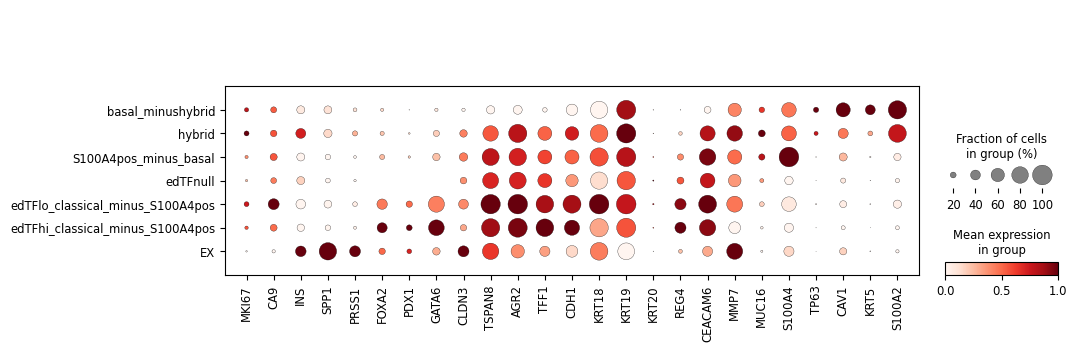

In [9]:
cols_with_EX = ['EX', 'edTFhi_classical_minus_S100A4pos', 'edTFlo_classical_minus_S100A4pos', 'edTFnull',
                'S100A4pos_minus_basal', 'hybrid', 'basal_minushybrid']

adata_ductal.obs['DE_group'] = 'none'
for c in cols_with_EX:
    adata_ductal.obs.loc[adata_ductal.obs[c], 'DE_group'] = c
adata_ductal.obs['DE_group'] = adata_ductal.obs['DE_group'].astype('category')

adata_de = adata_ductal[adata_ductal.obs['DE_group'] != 'none'].copy()
adata_de.obs['DE_group'] = adata_de.obs['DE_group'].cat.reorder_categories(list(reversed(cols_with_EX)))

genes_plot = ['MKI67','CA9','INS','SPP1','PRSS1','FOXA2','PDX1',
              'GATA6','CLDN3','TSPAN8','AGR2','TFF1','CDH1','KRT18',
              'KRT19','KRT20','REG4','CEACAM6','MMP7','MUC16','S100A4',
              'TP63','CAV1','KRT5','S100A2'
             ]

dp = sc.pl.dotplot(
    adata_de, genes_plot, groupby='DE_group', standard_scale='var',
    categories_order=list(reversed(cols_with_EX)),
    return_fig=True
)

dp.show()
ax = dp.get_axes()['mainplot_ax']
for label in ax.get_xticklabels():
    label.set_rotation(90)

dp.fig.savefig('dotplot_scRNAseq_epithelial.pdf', bbox_inches='tight')